In [2]:
!pip install python-igraph matplotlib networkit -q
!pip install python-igraph scipy matplotlib -q

In [32]:
import igraph as ig
import os
import heapq
import time
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import urllib.request
import glob


In [7]:
# 1. Find the uploaded .mtx file
files = [f for f in os.listdir('.') if f.endswith('.mtx')]
file_path = files[0]
print(f"Loading: {file_path}")

# 2. Bulletproof pure-Python .mtx parser
with open(file_path, 'r') as f:
    lines = f.readlines()

# Ignore comment lines starting with '%'
data_lines = [line.strip() for line in lines if not line.startswith('%') and line.strip()]

# First data line is dimensions (rows cols nnz)
dims = data_lines[0].split()
n_vertices = max(int(dims[0]), int(dims[1]))

# Remaining lines are edges (1-indexed)
edges = []
for line in data_lines[1:]:
    parts = line.split()
    u = int(parts[0]) - 1  # Convert to 0-indexed for Python
    v = int(parts[1]) - 1
    edges.append((u, v))

# 3. Build and clean the graph
G = ig.Graph(n=n_vertices, edges=edges, directed=False)
G.simplify() # Remove self-loops and multi-edges

print(f"✅ Success!")
print(f"Nodes: {G.vcount()}")
print(f"Edges: {G.ecount()}")

Loading: ca-netscience.mtx
✅ Success!
Nodes: 379
Edges: 913


In [8]:
def charikar_greedy(G):
    """
    Charikar's greedy peeling algorithm.
    Peels off min-degree vertices one by one,
    tracks density at each step, returns the best subgraph.
    """
    n = G.vcount()
    alive = set(range(n))

    # degree dict so we can update fast
    degree = {v: G.degree(v) for v in range(n)}

    # min-heap: (degree, vertex)
    heap = [(degree[v], v) for v in range(n)]
    heapq.heapify(heap)

    edge_count = G.ecount()
    best_density = 0.0
    best_alive = set(alive)
    removal_order = []

    # track history for the growth video later
    history = []

    while alive:
        cur_density = edge_count / len(alive)
        history.append((len(alive), edge_count, cur_density))

        if cur_density > best_density:
            best_density = cur_density
            best_alive = set(alive)  # snapshot

        # grab the min-degree alive vertex
        while heap:
            d, v = heapq.heappop(heap)
            if v in alive and d == degree[v]:
                break
        else:
            break

        removal_order.append(v)
        alive.remove(v)

        # update neighbor degrees
        for u in G.neighbors(v):
            if u in alive:
                degree[u] -= 1
                edge_count -= 1
                heapq.heappush(heap, (degree[u], u))

    # build the actual subgraph from the best snapshot
    densest = G.subgraph(list(best_alive))
    return densest, best_density, removal_order, history


# --- Run it on ca-netscience ---
start = time.time()
densest, density, removal, hist = charikar_greedy(G)
elapsed = time.time() - start

print(f"Original graph: {G.vcount()} nodes, {G.ecount()} edges")
print(f"Densest subgraph: {densest.vcount()} nodes, {densest.ecount()} edges")
print(f"Density: {density:.4f}")
print(f"Time: {elapsed:.4f}s")

Original graph: 379 nodes, 913 edges
Densest subgraph: 9 nodes, 36 edges
Density: 4.0000
Time: 0.0346s


In [12]:
def greedy_plus_plus(G, T=10):
    n = G.vcount()
    m = G.ecount()

    # start all edge weights at 1.0
    w = [1.0] * m
    best_density = 0.0
    best_nodes = set(range(n))

    for iteration in range(T):
        # 1. figure out current weighted degrees
        deg = [0.0] * n
        for i, e in enumerate(G.es):
            u, v = e.tuple
            deg[u] += w[i]
            deg[v] += w[i]

        alive = set(range(n))
        current_w_edges = sum(w)
        load = [0.0] * n

        # min-heap for peeling
        heap = [(deg[v], v) for v in range(n)]
        heapq.heapify(heap)

        while alive:
            density = current_w_edges / len(alive)

            if density > best_density:
                best_density = density
                best_nodes = set(alive)

            # pop the min weighted degree node
            while heap:
                d, v = heapq.heappop(heap)
                if v in alive and abs(d - deg[v]) < 1e-9:
                    break
            else:
                break

            alive.remove(v)
            load[v] = deg[v]

            # update neighbors
            for edge_id in G.incident(v):
                e = G.es[edge_id]
                u = e.tuple[0] if e.tuple[1] == v else e.tuple[1]

                if u in alive:
                    deg[u] -= w[e.index]
                    current_w_edges -= w[e.index]
                    heapq.heappush(heap, (deg[u], u))

        # 2. update edge weights for the next round
        # Normalize by max_load to prevent exponential float overflow
        max_l = max(load)
        if max_l == 0:
            max_l = 1.0

        for i, e in enumerate(G.es):
            u, v = e.tuple
            # factor is now bounded by 1.0, preventing explosion
            # while still penalizing edges connected to low-load nodes
            factor = (load[u] + load[v]) / (2.0 * max_l)
            w[i] *= factor

    densest = G.subgraph(list(best_nodes))
    return densest, best_density


# run it
start = time.time()
densest_pp, density_pp = greedy_plus_plus(G, T=10)
elapsed_pp = time.time() - start

print(f"Greedy++ Densest subgraph: {densest_pp.vcount()} nodes, {densest_pp.ecount()} edges")
print(f"Greedy++ Density: {density_pp:.4f}")
print(f"Time: {elapsed_pp:.4f}s")

Greedy++ Densest subgraph: 9 nodes, 36 edges
Greedy++ Density: 4.0000
Time: 0.0501s


In [14]:
def goldberg_exact(G):
    """
    Goldberg's exact algorithm for densest subgraph using parametric max-flow.
    Binary searches on the density parameter g and solves a min-cut problem.
    """
    n = G.vcount()
    m = G.ecount()

    # density is bounded by 0 and the maximum degree in the graph
    low = 0.0
    high = float(max(G.degree()))

    best_nodes = set()
    best_density = 0.0

    # precision for the binary search (1/(n*(n-1)) is the theoretical minimum gap)
    eps = 1.0 / (n * (n - 1)) if n > 1 else 1.0

    while high - low > eps:
        mid = (low + high) / 2.0

        # build the directed flow network for this guess 'mid'
        flow_G = nx.DiGraph()
        s = n      # source node
        t = n + 1  # sink node

        for v in range(n):
            # edge from source to v
            flow_G.add_edge(s, v, capacity=m)

            # edge from v to sink. capacity must be non-negative
            cap_vt = m + 2 * mid - G.degree(v)
            flow_G.add_edge(v, t, capacity=max(0.0, cap_vt))

        # add the original undirected edges as directed edges with capacity 1
        for u, v in G.get_edgelist():
            flow_G.add_edge(u, v, capacity=1.0)
            flow_G.add_edge(v, u, capacity=1.0)

        # find the minimum s-t cut
        cut_val, partition = nx.minimum_cut(flow_G, s, t)
        reachable, _ = partition

        # the candidate subgraph is the reachable set minus the source
        subgraph_nodes = reachable - {s}

        # if the cut value is less than m*n, the source side isn't just {s}
        # meaning we found a valid subgraph with density >= mid
        if cut_val < m * n and len(subgraph_nodes) > 0:
            low = mid
            best_nodes = subgraph_nodes

            # calculate the actual density of this exact subgraph
            sub_g = G.subgraph(list(best_nodes))
            best_density = sub_g.ecount() / len(best_nodes)
        else:
            # no subgraph found with this density, search lower
            high = mid

    return best_nodes, best_density

# --- Run Goldberg's on ca-netscience ---
start = time.time()
exact_nodes, exact_density = goldberg_exact(G)
elapsed_gold = time.time() - start

print(f"Goldberg Exact Densest subgraph: {len(exact_nodes)} nodes")
# count edges in the exact subgraph
exact_edges = G.subgraph(list(exact_nodes)).ecount()
print(f"Goldberg Exact Edges: {exact_edges}")
print(f"Goldberg Exact Density: {exact_density:.4f}")
print(f"Time: {elapsed_gold:.4f}s")

Goldberg Exact Densest subgraph: 13 nodes
Goldberg Exact Edges: 52
Goldberg Exact Density: 4.0000
Time: 0.7124s


In [17]:
def exact_triangle_density(G):
    """
    Exact algorithm for Triangle-Densest Subgraph using max-flow reduction.
    """
    n = G.vcount()

    # Convert igraph to networkx for triangle finding and flow
    nx_G = nx.Graph()
    nx_G.add_nodes_from(range(n))
    nx_G.add_edges_from(G.get_edgelist())

    # 1. Find all triangles efficiently (much faster than enumerate_all_cliques)
    triangles = set()
    for u, v in nx_G.edges():
        # find common neighbors of u and v
        for w in set(nx_G.neighbors(u)) & set(nx_G.neighbors(v)):
            tri = tuple(sorted((u, v, w)))
            triangles.add(tri)
    triangles = list(triangles)
    total_triangles = len(triangles)

    if total_triangles == 0:
        return set(), 0.0

    # Count how many triangles each vertex participates in
    t_v = {v: 0 for v in range(n)}
    for tri in triangles:
        for v in tri:
            t_v[v] += 1

    # 2. Binary search for the exact maximum triangle density
    low = 0.0
    high = float(total_triangles)

    best_nodes = set()
    best_density = 0.0

    # Precision: 1/(n*(n-1)*(n-2)) is the theoretical minimum gap
    eps = 1.0 / (n * (n - 1) * (n - 2)) if n > 2 else 1.0

    while high - low > eps:
        alpha = (low + high) / 2.0

        # Build the flow network for this guess 'alpha'
        flow_G = nx.DiGraph()
        s = n          # source node
        t = n + 1      # sink node

        tri_to_id = {}
        next_id = n + 2

        for tri in triangles:
            tri_to_id[tri] = next_id
            next_id += 1

        # Add edges from source to each vertex v with capacity t_v
        for v in range(n):
            flow_G.add_edge(s, v, capacity=float(t_v[v]))
            flow_G.add_edge(v, t, capacity=3.0 * alpha)

        # Add edges for each triangle
        for tri, tri_id in tri_to_id.items():
            u, v, w = tri
            # Edges from vertices to triangle node (capacity 1)
            flow_G.add_edge(u, tri_id, capacity=1.0)
            flow_G.add_edge(v, tri_id, capacity=1.0)
            flow_G.add_edge(w, tri_id, capacity=1.0)

            # Edges from triangle node to vertices (capacity 2)
            flow_G.add_edge(tri_id, u, capacity=2.0)
            flow_G.add_edge(tri_id, v, capacity=2.0)
            flow_G.add_edge(tri_id, w, capacity=2.0)

        # Find the minimum s-t cut
        cut_val, partition = nx.minimum_cut(flow_G, s, t)
        reachable, _ = partition

        # The candidate subgraph is the reachable set minus the source and triangle nodes
        subgraph_nodes = {node for node in reachable if node < n}

        # If the cut value is strictly less than the total capacity out of source,
        # we found a valid subgraph with density >= alpha
        if cut_val < 3.0 * total_triangles - 1e-9 and len(subgraph_nodes) > 0:
            low = alpha
            best_nodes = subgraph_nodes

            # Calculate the actual triangle density of this exact subgraph
            sub_nx_G = nx_G.subgraph(list(best_nodes))
            tri_count = 0
            for u, v in sub_nx_G.edges():
                for w in set(sub_nx_G.neighbors(u)) & set(sub_nx_G.neighbors(v)):
                    tri_count += 1
            tri_count //= 3  # each triangle is counted 3 times (once per edge)
            best_density = tri_count / len(best_nodes)
        else:
            high = alpha

    return best_nodes, best_density


# --- Run Exact Triangle-Density on ca-netscience ---
print("Finding triangles and running exact algorithm...")
start = time.time()
tri_nodes, tri_density = exact_triangle_density(G)
elapsed_tri = time.time() - start

print(f"Exact Triangle-Density subgraph: {len(tri_nodes)} nodes")

# count triangles in the exact subgraph for the final print
nx_G_full = nx.Graph()
nx_G_full.add_nodes_from(range(G.vcount()))
nx_G_full.add_edges_from(G.get_edgelist())
sub_nx_G = nx_G_full.subgraph(list(tri_nodes))
tri_count = 0
for u, v in sub_nx_G.edges():
    for w in set(sub_nx_G.neighbors(u)) & set(sub_nx_G.neighbors(v)):
        tri_count += 1
tri_count //= 3

print(f"Triangles in subgraph: {tri_count}")
print(f"Triangle Density: {tri_density:.4f}")
print(f"Time: {elapsed_tri:.4f}s")

Finding triangles and running exact algorithm...
Exact Triangle-Density subgraph: 9 nodes
Triangles in subgraph: 84
Triangle Density: 9.3333
Time: 2.9015s


In [20]:
def animate_densest_growth(G, removal_order, filename="ca_netscience_growth.gif"):
    """
    Creates an animation of the densest subgraph being built in reverse
    of the peeling order (showing the core forming).
    """
    # Animate the last 15 removals (the core forming)
    animate_count = min(15, len(removal_order))
    core_nodes = removal_order[-animate_count:][::-1] # Reverse to show growth

    # Create an igraph subgraph of just these nodes, then convert to networkx
    H_ig = G.subgraph(core_nodes)
    nx_H = nx.Graph()
    nx_H.add_nodes_from(core_nodes)
    nx_H.add_edges_from(H_ig.get_edgelist())

    # Fixed layout so nodes don't jump around between frames
    pos = nx.spring_layout(nx_H, seed=42)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title("Incremental Densest Subgraph Construction")
    ax.axis('off')

    def update(frame):
        ax.clear()
        ax.set_title(f"Step {frame+1}/{len(core_nodes)}")
        ax.axis('off')

        # Nodes to show at this frame
        current_nodes = core_nodes[:frame+1]
        sub_nx_H = nx_H.subgraph(current_nodes)

        # Draw edges first, then nodes, then labels
        nx.draw_networkx_edges(sub_nx_H, pos, ax=ax, edge_color='gray', width=1.5)
        nx.draw_networkx_nodes(sub_nx_H, pos, ax=ax, node_color='#4C72B0', node_size=300)
        nx.draw_networkx_labels(sub_nx_H, pos, ax=ax, font_size=8)

        return ax,

    ani = animation.FuncAnimation(fig, update, frames=len(core_nodes), interval=500, blit=False)

    # Save as GIF using Pillow (built-in, no ffmpeg needed)
    ani.save(filename, writer='pillow', fps=2)
    plt.close()
    print(f"✅ Animation saved as {filename}")

# --- Run the animation for ca-netscience ---
# Re-run Charikar's quickly to ensure we have the removal_order in scope
densest, density, removal, hist = charikar_greedy(G)

print("Generating animation (this takes ~10 seconds)...")
animate_densest_growth(G, removal, filename="ca_netscience_growth.gif")

Generating animation (this takes ~10 seconds)...
✅ Animation saved as ca_netscience_growth.gif



--- Benchmarking ca-netscience ---
Loading ca-netscience...
Size: 379 nodes, 913 edges

--- Benchmarking ca-CSphd ---
Loading ca-CSphd...
Size: 1882 nodes, 1739 edges

--- Benchmarking ca-GrQc ---
Loading ca-GrQc...
Size: 4158 nodes, 13422 edges

--- Benchmarking ca-HepTh ---
Loading ca-HepTh...
Size: 9877 nodes, 25973 edges

✅ Benchmarking complete!
✅ Master plot saved as computational_cost_plot.png


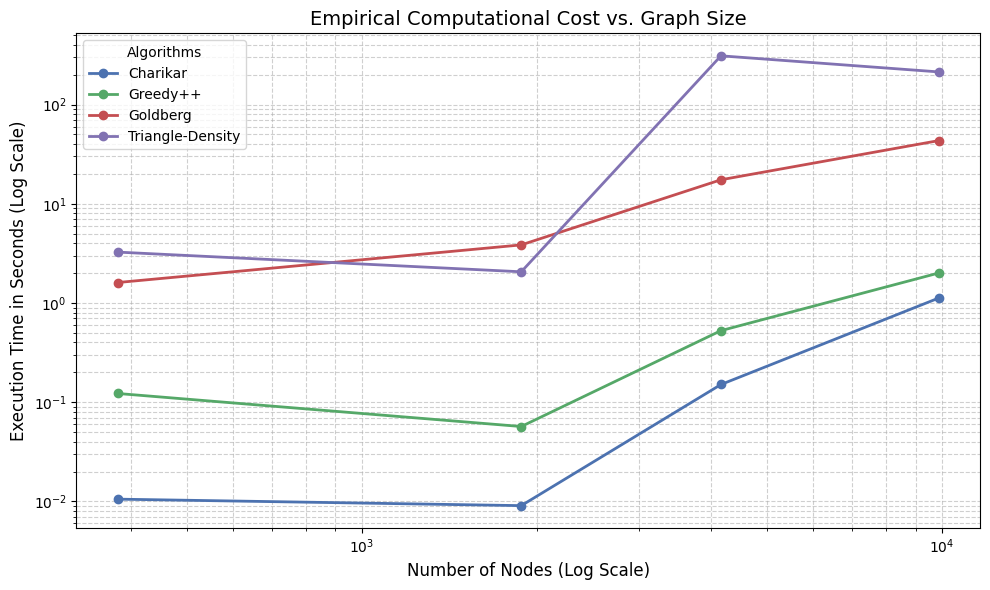

In [29]:
# ==========================================
# 1. ALGORITHM DEFINITIONS
# ==========================================
def charikar_greedy(G):
    n = G.vcount()
    alive = set(range(n))
    degree = {v: G.degree(v) for v in range(n)}
    heap = [(degree[v], v) for v in range(n)]
    heapq.heapify(heap)

    edge_count = G.ecount()
    best_density = 0.0
    best_alive = set(alive)
    removal_order = []

    while alive:
        cur_density = edge_count / len(alive)
        if cur_density > best_density:
            best_density = cur_density
            best_alive = set(alive)

        while heap:
            d, v = heapq.heappop(heap)
            if v in alive and d == degree[v]:
                break
        else:
            break

        removal_order.append(v)
        alive.remove(v)
        for u in G.neighbors(v):
            if u in alive:
                degree[u] -= 1
                edge_count -= 1
                heapq.heappush(heap, (degree[u], u))

    densest = G.subgraph(list(best_alive))
    return densest, best_density, removal_order, []

def greedy_plus_plus(G, T=5):
    n = G.vcount()
    m = G.ecount()
    w = [1.0] * m
    best_density = 0.0
    best_nodes = set(range(n))

    for _ in range(T):
        deg = [0.0] * n
        for i, e in enumerate(G.es):
            u, v = e.tuple
            deg[u] += w[i]; deg[v] += w[i]

        alive = set(range(n))
        current_w_edges = sum(w)
        load = [0.0] * n
        heap = [(deg[v], v) for v in range(n)]
        heapq.heapify(heap)

        while alive:
            density = current_w_edges / len(alive)
            if density > best_density:
                best_density = density
                best_nodes = set(alive)

            while heap:
                d, v = heapq.heappop(heap)
                if v in alive and abs(d - deg[v]) < 1e-9: break
            else: break

            alive.remove(v)
            load[v] = deg[v]
            for edge_id in G.incident(v):
                e = G.es[edge_id]
                u = e.tuple[0] if e.tuple[1] == v else e.tuple[1]
                if u in alive:
                    deg[u] -= w[e.index]
                    current_w_edges -= w[e.index]
                    heapq.heappush(heap, (deg[u], u))

        max_l = max(load) if max(load) > 0 else 1.0
        for i, e in enumerate(G.es):
            u, v = e.tuple
            w[i] *= (load[u] + load[v]) / (2.0 * max_l)

    return G.subgraph(list(best_nodes)), best_density

def goldberg_exact_igraph(G):
    n = G.vcount()
    m = G.ecount()
    low = 0.0
    high = float(max(G.degree()))
    best_nodes = set()
    best_density = 0.0
    eps = 1.0 / (n * (n - 1)) if n > 1 else 1.0

    nx_G = nx.Graph()
    nx_G.add_nodes_from(range(n))
    nx_G.add_edges_from(G.get_edgelist())

    while high - low > eps:
        mid = (low + high) / 2.0
        flow_G = nx.DiGraph()
        s, t = n, n + 1

        for v in range(n):
            flow_G.add_edge(s, v, capacity=m)
            flow_G.add_edge(v, t, capacity=max(0.0, m + 2 * mid - G.degree(v)))

        for u, v in nx_G.edges():
            flow_G.add_edge(u, v, capacity=1.0)
            flow_G.add_edge(v, u, capacity=1.0)

        cut_val, partition = nx.minimum_cut(flow_G, s, t)
        reachable, _ = partition
        subgraph_nodes = reachable - {s}

        if cut_val < m * n and len(subgraph_nodes) > 0:
            low = mid
            best_nodes = subgraph_nodes
            sub_g = G.subgraph(list(best_nodes))
            best_density = sub_g.ecount() / len(best_nodes)
        else:
            high = mid

    return best_nodes, best_density

def exact_triangle_density_igraph(G):
    n = G.vcount()
    nx_G = nx.Graph()
    nx_G.add_nodes_from(range(n))
    nx_G.add_edges_from(G.get_edgelist())

    triangles = set()
    for u, v in nx_G.edges():
        for w in set(nx_G.neighbors(u)) & set(nx_G.neighbors(v)):
            triangles.add(tuple(sorted((u, v, w))))
    triangles = list(triangles)
    total_triangles = len(triangles)

    if total_triangles == 0: return set(), 0.0

    t_v = {v: 0 for v in range(n)}
    for tri in triangles:
        for v in tri: t_v[v] += 1

    low, high = 0.0, float(total_triangles)
    best_nodes, best_density = set(), 0.0
    eps = 1.0 / (n * (n - 1) * (n - 2)) if n > 2 else 1.0

    while high - low > eps:
        alpha = (low + high) / 2.0
        flow_G = nx.DiGraph()
        s, t = n, n + 1
        tri_to_id = {tri: n + 2 + i for i, tri in enumerate(triangles)}

        for v in range(n):
            flow_G.add_edge(s, v, capacity=float(t_v[v]))
            flow_G.add_edge(v, t, capacity=3.0 * alpha)

        for tri, tri_id in tri_to_id.items():
            u, v, w = tri
            for node in (u, v, w):
                flow_G.add_edge(node, tri_id, capacity=1.0)
                flow_G.add_edge(tri_id, node, capacity=2.0)

        cut_val, partition = nx.minimum_cut(flow_G, s, t)
        reachable, _ = partition
        subgraph_nodes = {node for node in reachable if node < n}

        if cut_val < 3.0 * total_triangles - 1e-9 and len(subgraph_nodes) > 0:
            low = alpha
            best_nodes = subgraph_nodes
            sub_nx_G = nx_G.subgraph(list(best_nodes))
            tri_count = sum(1 for u, v in sub_nx_G.edges() for w in set(sub_nx_G.neighbors(u)) & set(sub_nx_G.neighbors(v))) // 3
            best_density = tri_count / len(best_nodes)
        else:
            high = alpha

    return best_nodes, best_density

# ==========================================
# 2. LOCAL FILE LOADER
# ==========================================
def load_graph_from_file(name):
    print(f"Loading {name}...")
    file_path = f"{name}.mtx"
    if not os.path.exists(file_path):
        matches = glob.glob(f"*{name}*.mtx")
        if matches:
            file_path = matches[0]
        else:
            raise FileNotFoundError(f"Please upload {name}.mtx to the left sidebar.")

    with open(file_path, 'r') as f:
        lines = f.readlines()
    data_lines = [line.strip() for line in lines if not line.startswith('%') and line.strip()]
    dims = data_lines[0].split()
    n_vertices = max(int(dims[0]), int(dims[1]))
    edges = []
    for line in data_lines[1:]:
        parts = line.split()
        edges.append((int(parts[0]) - 1, int(parts[1]) - 1))

    G = ig.Graph(n=n_vertices, edges=edges, directed=False)
    G.simplify()
    return G

# ==========================================
# 3. BENCHMARKING LOOP
# ==========================================
# Only the 4 datasets we have
datasets = ["ca-netscience", "ca-CSphd", "ca-GrQc", "ca-HepTh"]

results = {
    "Dataset": [], "Nodes": [], "Edges": [],
    "Charikar (s)": [], "Greedy++ (s)": [],
    "Goldberg (s)": [], "Triangle-Density (s)": []
}

for name in datasets:
    print(f"\n--- Benchmarking {name} ---")
    G = load_graph_from_file(name)
    n, m = G.vcount(), G.ecount()
    print(f"Size: {n} nodes, {m} edges")

    results["Dataset"].append(name)
    results["Nodes"].append(n)
    results["Edges"].append(m)

    # 1. Charikar
    try:
        start = time.time()
        charikar_greedy(G)
        results["Charikar (s)"].append(time.time() - start)
    except Exception as e:
        results["Charikar (s)"].append(None); print(f"Charikar failed: {e}")

    # 2. Greedy++
    try:
        start = time.time()
        greedy_plus_plus(G, T=5)
        results["Greedy++ (s)"].append(time.time() - start)
    except Exception as e:
        results["Greedy++ (s)"].append(None); print(f"Greedy++ failed: {e}")

    # 3. Goldberg
    try:
        start = time.time()
        goldberg_exact_igraph(G)
        results["Goldberg (s)"].append(time.time() - start)
    except Exception as e:
        results["Goldberg (s)"].append(None); print(f"Goldberg failed/skipped: {e}")

    # 4. Triangle Density
    try:
        start = time.time()
        exact_triangle_density_igraph(G)
        results["Triangle-Density (s)"].append(time.time() - start)
    except Exception as e:
        results["Triangle-Density (s)"].append(None)
        print(f"Triangle-Density failed: {e}")

print("\n✅ Benchmarking complete!")

# ==========================================
# 4. GENERATE MASTER PLOT
# ==========================================
plt.figure(figsize=(10, 6))
algorithms = ["Charikar (s)", "Greedy++ (s)", "Goldberg (s)", "Triangle-Density (s)"]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for alg, color in zip(algorithms, colors):
    valid_idx = [i for i, val in enumerate(results[alg]) if val is not None]
    valid_nodes = [results["Nodes"][i] for i in valid_idx]
    valid_times = [results[alg][i] for i in valid_idx]

    if valid_nodes:
        plt.plot(valid_nodes, valid_times, marker='o', label=alg.replace(" (s)", ""), color=color, linewidth=2)

plt.title("Empirical Computational Cost vs. Graph Size", fontsize=14)
plt.xlabel("Number of Nodes (Log Scale)", fontsize=12)
plt.ylabel("Execution Time in Seconds (Log Scale)", fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(title="Algorithms", fontsize=10)
plt.tight_layout()

plt.savefig("computational_cost_plot.png", dpi=300)
print("✅ Master plot saved as computational_cost_plot.png")
plt.show()